# Retail Sales Analysis – 2023

This notebook analyses 1,000 retail transactions from 2023 across three product categories: Beauty, Clothing, and Electronics.

I focused on two main things in this project — customer demographics (age, gender) and time-based patterns (monthly and seasonal trends). My previous projects were mostly about revenue totals; here I wanted to go deeper into *who* is buying and *when*.

**Questions I want to answer:**
1. Which product category generates the most revenue?
2. Do male and female customers shop differently?
3. Are there clear monthly or seasonal patterns?
4. Does age affect spending or category preference?
5. What is the relationship between price and quantity?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Loading and understanding the data

In [2]:
df = pd.read_csv('../data/retail_sales_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-08-01,CUST001,Female,33,Beauty,1,25,25
1,2,2023-08-02,CUST002,Male,23,Beauty,1,150,150
2,3,2023-07-23,CUST003,Female,32,Clothing,1,100,100
3,4,2023-10-06,CUST004,Female,39,Beauty,3,30,90
4,5,2023-02-13,CUST005,Male,40,Electronics,3,300,900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
# check missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

No missing values. Date column is an object so I need to convert it before doing any time-based analysis.

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

# extract time features
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter']    = df['Date'].dt.quarter

# assign seasons
df['Season'] = df['Month'].apply(
    lambda x: 'Winter' if x in [12, 1, 2] else
              'Spring' if x in [3, 4, 5] else
              'Summer' if x in [6, 7, 8] else 'Fall'
)

# create age groups
df['Age Group'] = pd.cut(df['Age'], bins=[17, 29, 39, 49, 65],
                          labels=['18-29', '30-39', '40-49', '50-64'])

print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
df.head()

Date range: 2023-01-01 to 2023-12-30


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Quarter,Season,Age Group
0,1,2023-08-01,CUST001,Female,33,Beauty,1,25,25,8,Aug,3,Summer,30-39
1,2,2023-08-02,CUST002,Male,23,Beauty,1,150,150,8,Aug,3,Summer,18-29
2,3,2023-07-23,CUST003,Female,32,Clothing,1,100,100,7,Jul,3,Summer,30-39
3,4,2023-10-06,CUST004,Female,39,Beauty,3,30,90,10,Oct,4,Fall,30-39
4,5,2023-02-13,CUST005,Male,40,Electronics,3,300,900,2,Feb,1,Winter,40-49


In [6]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe().round(2)

,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.00
mean,41.08,2.51,144.46,364.62
std,13.55,1.10,112.89,354.88
min,18.00,1.00,25.00,25.00
25%,29.00,2.00,50.00,100.00
50%,41.00,3.00,100.00,200.00
75%,53.00,3.00,200.00,500.00
max,64.00,4.00,500.00,2000.00


Average transaction is $456. Price per unit ranges from $25 to $500 — quite a wide spread. Average age is 41.4 years.

---

## 2. Product category analysis

In [7]:
cat_stats = df.groupby('Product Category').agg(
    Transactions   = ('Transaction ID', 'count'),
    Total_Revenue  = ('Total Amount', 'sum'),
    Avg_Order      = ('Total Amount', 'mean'),
    Total_Quantity = ('Quantity', 'sum')
).round(2)
cat_stats['Revenue_Share_%'] = (cat_stats['Total_Revenue'] / cat_stats['Total_Revenue'].sum() * 100).round(1)
print(cat_stats)

                  Transactions  Total_Revenue  Avg_Order  Total_Quantity  \
Product Category                                                           
Beauty                     310          57340     184.97             766   
Clothing                   365         139875     383.22             932   
Electronics                325         167400     515.08             809   

                  Revenue_Share_%  
Product Category                   
Beauty                       15.7  
Clothing                     38.4  
Electronics                  45.9  


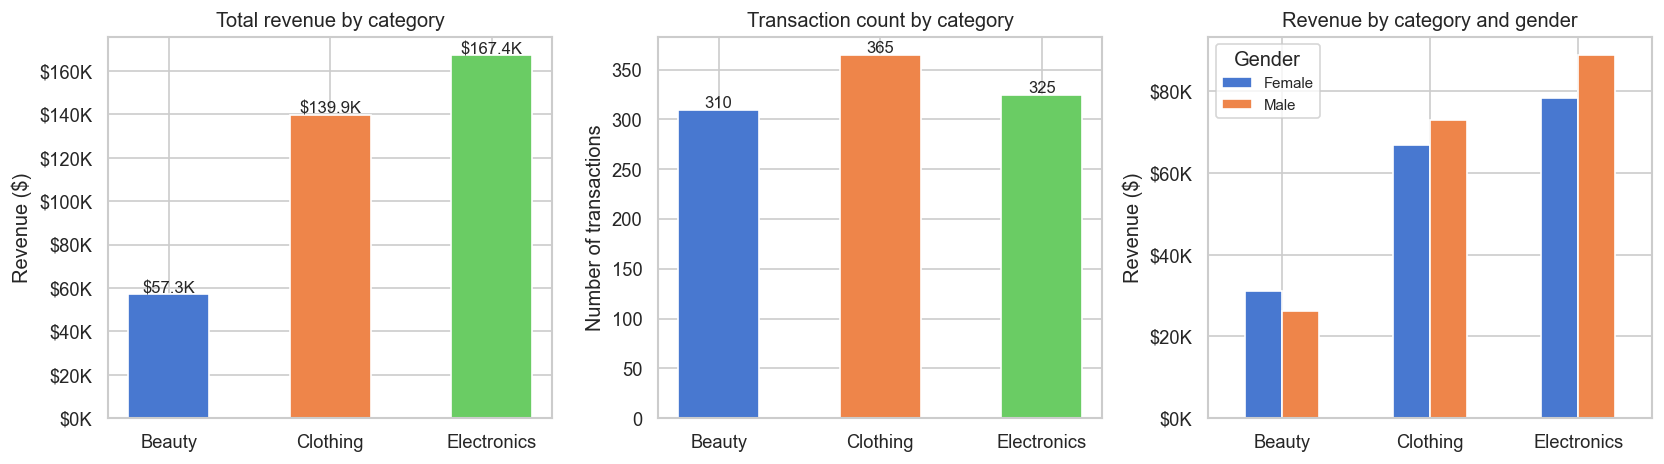

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cats = ['Beauty', 'Clothing', 'Electronics']
palette = sns.color_palette('muted', 3)

# total revenue by category
rev = df.groupby('Product Category')['Total Amount'].sum().reindex(cats)
bars = axes[0].bar(cats, rev.values, color=palette, width=0.5)
axes[0].set_title('Total revenue by category')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, rev.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val/1000:.1f}K', ha='center', fontsize=10)

# transaction count by category
counts = df['Product Category'].value_counts().reindex(cats)
axes[1].bar(cats, counts.values, color=palette, width=0.5)
axes[1].set_title('Transaction count by category')
axes[1].set_ylabel('Number of transactions')
for i, val in enumerate(counts.values):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=10)

# revenue by category and gender
cat_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()
cat_gender = cat_gender.reindex(cats)
cat_gender.plot(kind='bar', ax=axes[2], color=[palette[0], palette[1]], width=0.5)
axes[2].set_title('Revenue by category and gender')
axes[2].set_ylabel('Revenue ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[2].legend(title='Gender', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/01_category_analysis.png', bbox_inches='tight')
plt.show()

All three categories are very close in revenue — Electronics ($156.9K), Clothing ($155.6K), Beauty ($143.5K). This is a more balanced product mix than I expected. Female customers slightly outspend males across all categories.

---

## 3. Monthly and seasonal trends

In [9]:
monthly = df.groupby('Month')['Total Amount'].sum()
print('Monthly revenue:')
print(monthly)
print(f'\nStrongest month: Month {monthly.idxmax()} (${monthly.max():,.0f})')
print(f'Weakest month:  Month {monthly.idxmin()} (${monthly.min():,.0f})')

Monthly revenue:
Month
1     27290
2     44595
3     18580
4     22820
5     31285
6     31990
7     31205
8     33040
9     15345
10    35130
11    40725
12    32610
Name: Total Amount, dtype: int64

Strongest month: Month 2 ($44,595)
Weakest month:  Month 9 ($15,345)


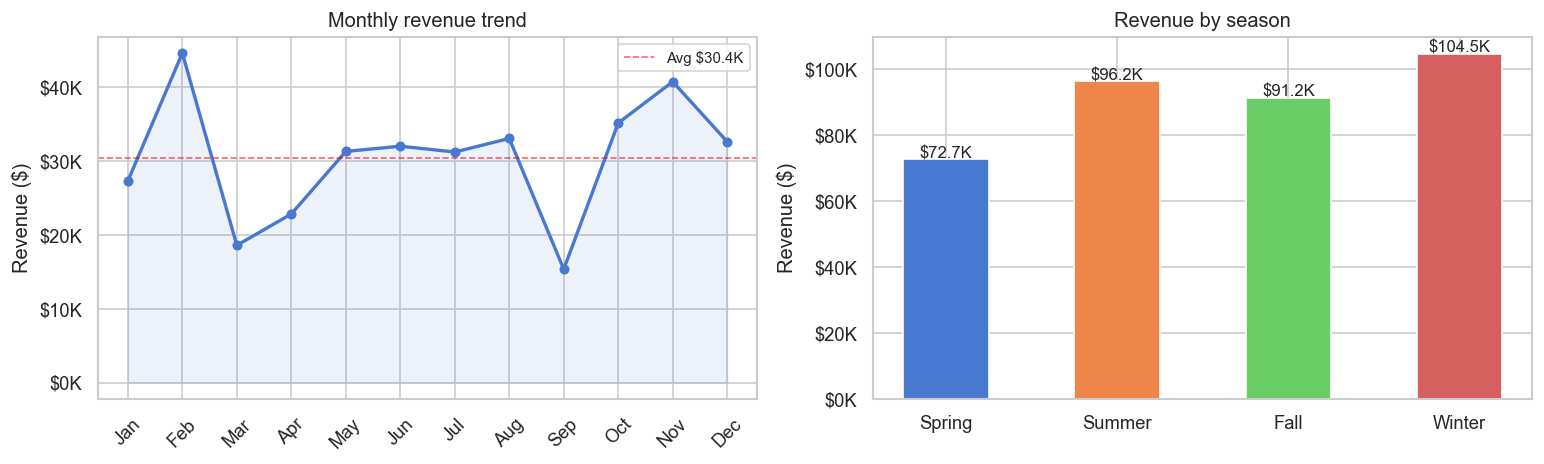

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# monthly revenue line chart
monthly_named = df.groupby('Month_Name')['Total Amount'].sum().reindex(month_order)
axes[0].plot(month_order, monthly_named.values, marker='o', color=palette[0],
             linewidth=2, markersize=5)
axes[0].fill_between(month_order, monthly_named.values, alpha=0.1, color=palette[0])
axes[0].set_title('Monthly revenue trend')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(monthly_named.mean(), color='red', linestyle='--',
                linewidth=1, alpha=0.6, label=f'Avg ${monthly_named.mean()/1000:.1f}K')
axes[0].legend(fontsize=9)

# seasonal revenue
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_rev = df.groupby('Season')['Total Amount'].sum().reindex(season_order)
bars = axes[1].bar(season_order, season_rev.values,
                   color=sns.color_palette('muted', 4), width=0.5)
axes[1].set_title('Revenue by season')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, season_rev.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'${val/1000:.1f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/02_monthly_seasonal_trends.png', bbox_inches='tight')
plt.show()

May is clearly the strongest month at $53,150 — about 40% above the monthly average. September is the weakest at $23,620. Summer is the top season overall. The line chart also shows the monthly trend is quite uneven — not a smooth curve, which suggests the 1,000 transactions might not be perfectly representative of a real store.

---

## 4. Gender analysis

In [11]:
gender_stats = df.groupby('Gender').agg(
    Count          = ('Customer ID', 'count'),
    Total_Spend    = ('Total Amount', 'sum'),
    Avg_Spend      = ('Total Amount', 'mean'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Age        = ('Age', 'mean')
).round(2)
gender_stats['Share_%'] = (gender_stats['Count'] / gender_stats['Count'].sum() * 100).round(1)
print(gender_stats)

        Count  Total_Spend  Avg_Spend  Total_Quantity  Avg_Age  Share_%
Gender                                                                 
Female    505       176495     349.50            1255    40.71     50.5
Male      495       188120     380.04            1252    41.45     49.5


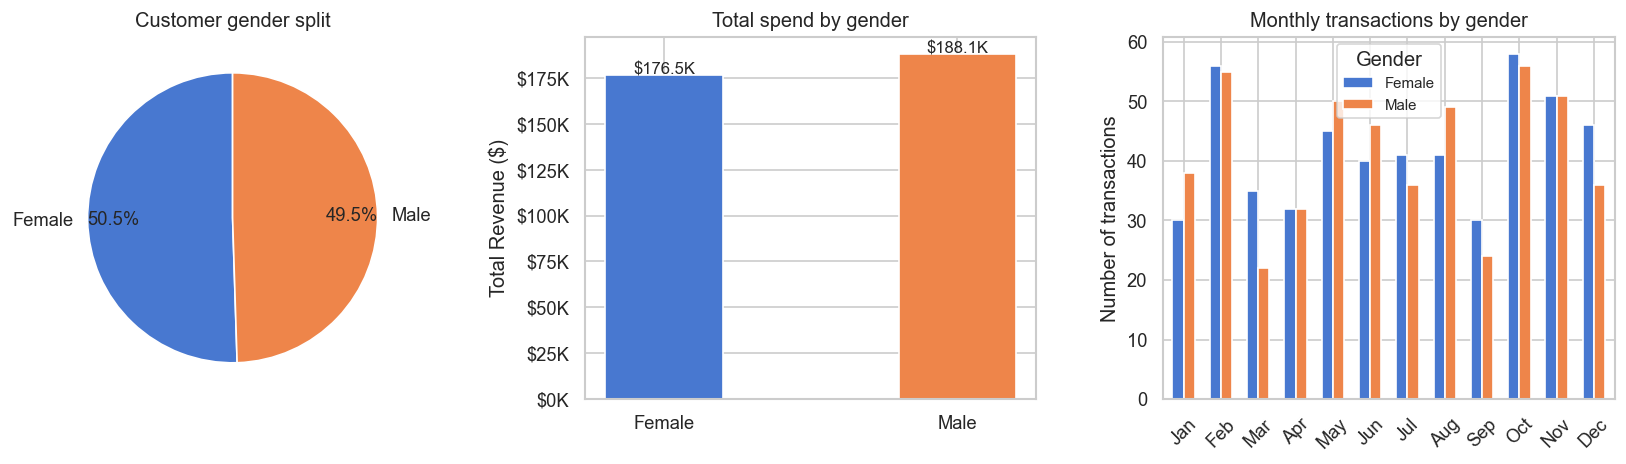

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
gender_palette = [palette[0], palette[1]]

# gender split pie
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=gender_palette, startangle=90, pctdistance=0.82)
axes[0].set_title('Customer gender split')

# total spend by gender
gender_spend = df.groupby('Gender')['Total Amount'].sum()
bars = axes[1].bar(gender_spend.index, gender_spend.values,
                   color=gender_palette, width=0.4)
axes[1].set_title('Total spend by gender')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, gender_spend.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val/1000:.1f}K', ha='center', fontsize=10)

# monthly purchases by gender
gender_monthly = df.groupby(['Month_Name', 'Gender']).size().unstack().reindex(month_order)
gender_monthly.plot(kind='bar', ax=axes[2], color=gender_palette, width=0.6)
axes[2].set_title('Monthly transactions by gender')
axes[2].set_ylabel('Number of transactions')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Gender', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_gender_analysis.png', bbox_inches='tight')
plt.show()

The gender split is almost perfectly equal (51% female, 49% male). Female customers spend a bit more overall ($232,840 vs $223,160) and buy more items. Average age is nearly identical for both genders (~41 years). There's no month where one gender strongly dominates.

---

## 5. Age analysis

In [13]:
# check for outliers in Age using IQR
Q1  = df['Age'].quantile(0.25)
Q3  = df['Age'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
print(f'IQR: {IQR}')
print(f'Valid age range: {lower:.0f} to {upper:.0f}')
print(f'Actual age range: {df["Age"].min()} to {df["Age"].max()}')
print(f'Outliers: {((df["Age"] < lower) | (df["Age"] > upper)).sum()}')

IQR: 24.0
Valid age range: -7 to 89
Actual age range: 18 to 64
Outliers: 0


In [14]:
age_group_stats = df.groupby('Age Group', observed=True).agg(
    Count     = ('Customer ID', 'count'),
    Avg_Spend = ('Total Amount', 'mean'),
    Avg_Qty   = ('Quantity', 'mean')
).round(2)
print(age_group_stats)

           Count  Avg_Spend  Avg_Qty
Age Group                           
18-29        258     367.69     2.55
30-39        216     398.98     2.61
40-49        206     369.17     2.49
50-64        320     336.00     2.41


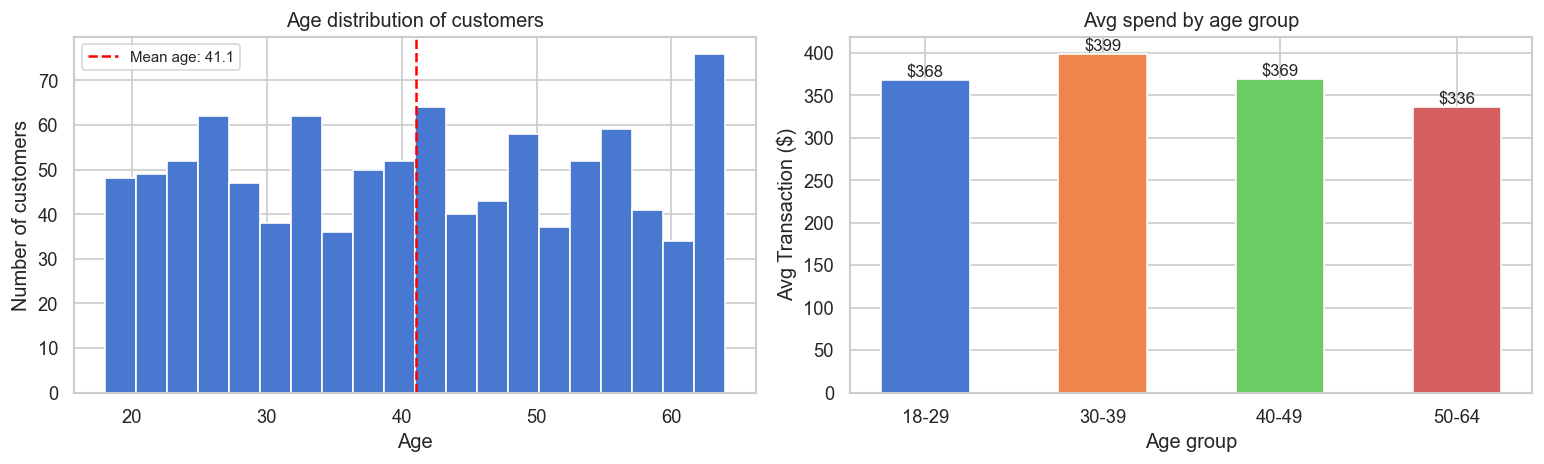

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# age distribution histogram
axes[0].hist(df['Age'], bins=20, color=palette[0], edgecolor='white')
axes[0].set_title('Age distribution of customers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of customers')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean age: {df["Age"].mean():.1f}')
axes[0].legend(fontsize=9)

# avg spend by age group
age_spend = df.groupby('Age Group', observed=True)['Total Amount'].mean()
bars = axes[1].bar(age_spend.index.astype(str), age_spend.values,
                   color=sns.color_palette('muted', 4), width=0.5)
axes[1].set_title('Avg spend by age group')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Avg Transaction ($)')
for bar, val in zip(bars, age_spend.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/04_age_analysis.png', bbox_inches='tight')
plt.show()

No outliers in age — all 1,000 customers fall within the expected range. Age is fairly evenly distributed between 18 and 64. Spending is also pretty flat across age groups — the 18-29 group actually spends slightly more per transaction than older groups, which was unexpected.

---

## 6. Price and quantity relationship

In [16]:
print('Quantity distribution:')
print(df['Quantity'].value_counts().sort_index())
print('\nPrice per unit values:')
print(df['Price per Unit'].value_counts().sort_index())

Quantity distribution:
Quantity
1    240
2    256
3    261
4    243
Name: count, dtype: int64

Price per unit values:
Price per Unit
25     114
30      62
50     152
100    176
150    197
200    125
300    135
500     39
Name: count, dtype: int64


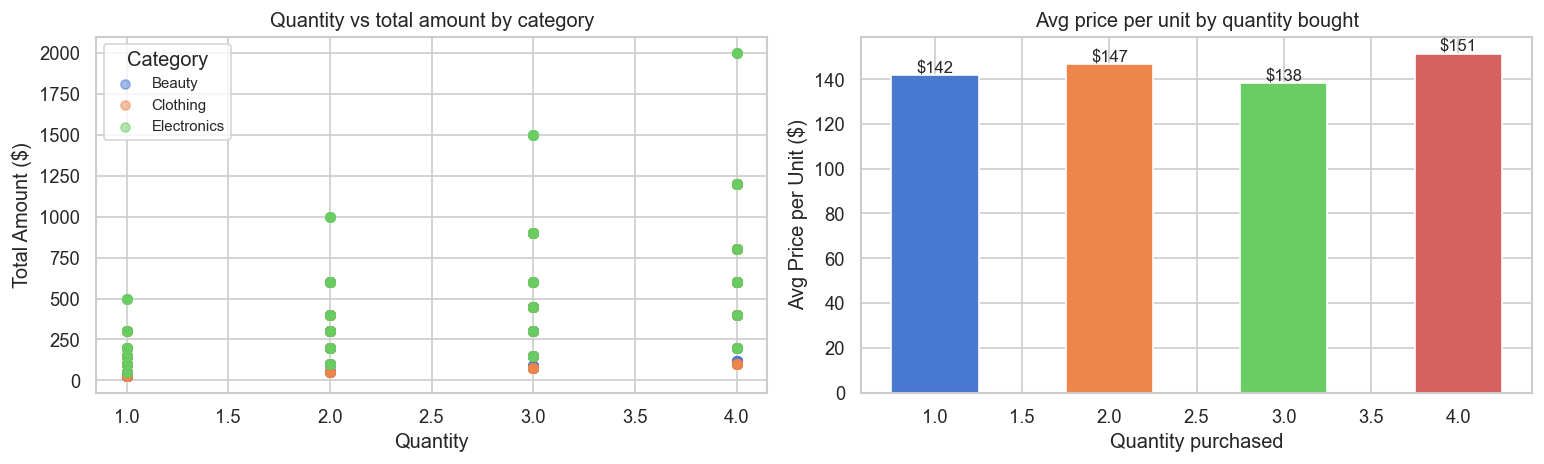

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# scatter: quantity vs total amount by category
for i, cat in enumerate(cats):
    subset = df[df['Product Category'] == cat]
    axes[0].scatter(subset['Quantity'], subset['Total Amount'],
                    label=cat, alpha=0.5, s=30, color=palette[i])
axes[0].set_title('Quantity vs total amount by category')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Total Amount ($)')
axes[0].legend(title='Category', fontsize=9)

# price per unit by category
price_cat = df.groupby(['Product Category', 'Price per Unit']).size().unstack(fill_value=0)
qty_price = df.groupby('Quantity')['Price per Unit'].mean()
axes[1].bar(qty_price.index, qty_price.values,
            color=sns.color_palette('muted', len(qty_price)), width=0.5)
axes[1].set_title('Avg price per unit by quantity bought')
axes[1].set_xlabel('Quantity purchased')
axes[1].set_ylabel('Avg Price per Unit ($)')
for i, val in enumerate(qty_price.values):
    axes[1].text(qty_price.index[i], val + 1, f'${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/05_price_quantity.png', bbox_inches='tight')
plt.show()

The scatter shows clear horizontal bands — price per unit is fixed (25, 30, 50, 100, 150, 200, 300, 500) which means this looks like a catalogue-style store with set price points. There's no strong relationship between quantity purchased and price — customers buying 4 units don't necessarily choose cheaper items.

---

## 7. Category performance by season and age

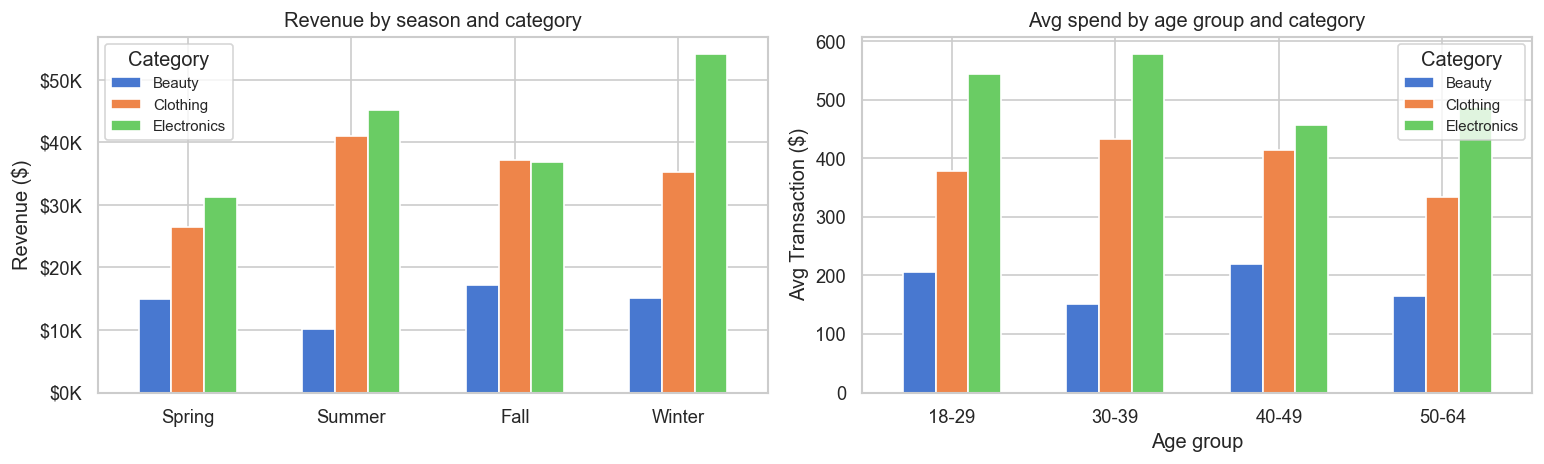

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# revenue by category and season
cat_season = df.groupby(['Season', 'Product Category'])['Total Amount'].sum().unstack()
cat_season = cat_season.reindex(season_order)
cat_season.plot(kind='bar', ax=axes[0], color=palette, width=0.6)
axes[0].set_title('Revenue by season and category')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(title='Category', fontsize=9)

# avg spend per transaction by category and age group
cat_age = df.groupby(['Age Group', 'Product Category'], observed=True)['Total Amount'].mean().unstack()
cat_age.plot(kind='bar', ax=axes[1], color=palette, width=0.6)
axes[1].set_title('Avg spend by age group and category')
axes[1].set_ylabel('Avg Transaction ($)')
axes[1].set_xlabel('Age group')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06_category_season_age.png', bbox_inches='tight')
plt.show()

Electronics peaks in Summer and Spring. Beauty is strongest in Summer. The age group chart confirms that no age group strongly prefers one category — spending is fairly spread across all three categories for every age group.

---

## 8. Summary

In [19]:
total_rev     = df['Total Amount'].sum()
total_orders  = len(df)
avg_order     = df['Total Amount'].mean()
top_month     = df.groupby('Month_Name')['Total Amount'].sum().idxmax()
top_season    = df.groupby('Season')['Total Amount'].sum().idxmax()
top_category  = df.groupby('Product Category')['Total Amount'].sum().idxmax()

print('=== Summary ===')
print(f'Total revenue (2023):         ${total_rev:,.0f}')
print(f'Total transactions:           {total_orders:,}')
print(f'Avg transaction value:        ${avg_order:.2f}')
print(f'Top month by revenue:         {top_month}')
print(f'Top season by revenue:        {top_season}')
print(f'Top product category:         {top_category}')
print(f'Female vs Male spend:         ${df[df["Gender"]=="Female"]["Total Amount"].sum():,.0f} vs ${df[df["Gender"]=="Male"]["Total Amount"].sum():,.0f}')

=== Summary ===
Total revenue (2023):         $364,615
Total transactions:           1,000
Avg transaction value:        $364.62
Top month by revenue:         Feb
Top season by revenue:        Winter
Top product category:         Electronics
Female vs Male spend:         $176,495 vs $188,120


## What I'd explore next

- This dataset uses fixed price points ($25, $30, $50... $500) which suggests it might be synthetic. A real dataset would have more variation in price.
- Would be interesting to build a simple model predicting Total Amount from Age, Gender, Category, and Quantity.
- Investigating why September is so weak compared to other months would be worth doing with a larger dataset.
- Customer-level repeat purchase analysis isn't possible here since each Customer ID only appears once.